# Exploratory Data Analysis - WildChat-1M Preprocessing V2

**Version 2 Update**: Removed code/instructional content filtering for maximum data availability.

This notebook:
1. Loads the raw WildChat-1M dataset
2. Tests the preprocessing pipeline on a sample (V2 - no code filtering)
3. Applies preprocessing to the full dataset
4. Saves both sample and full preprocessed datasets with `_v2` suffix
5. Performs basic EDA on the preprocessed data

In [ ]:
import pandas as pd
import numpy as np
import sys
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('../scripts')

from preprocessing import preprocess_wildchat, get_preprocessing_stats

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Raw Data

In [ ]:
raw_data_path = '../data/raw/wildchat_1M.csv'
sample_output_path = '../data/filtered/wildchat_sample_preprocessed_v2.csv'
full_output_path = '../data/filtered/wildchat_full_preprocessed_v2.csv'
os.makedirs('../data/filtered', exist_ok=True)

print(f"Loading raw data from: {raw_data_path}")
df_raw = pd.read_csv(raw_data_path)
print(f"\nRaw dataset shape: {df_raw.shape}")
print(f"\ncolumns: {list(df_raw.columns)}")
df_raw.head()

Loading raw data from: ../data/raw/wildchat_1M.csv

Raw dataset shape: (837989, 14)

Columns: ['conversation_hash', 'model', 'timestamp', 'conversation', 'turn', 'language', 'openai_moderation', 'detoxify_moderation', 'toxic', 'redacted', 'state', 'country', 'hashed_ip', 'header']

First few rows:

Raw dataset shape: (837989, 14)

Columns: ['conversation_hash', 'model', 'timestamp', 'conversation', 'turn', 'language', 'openai_moderation', 'detoxify_moderation', 'toxic', 'redacted', 'state', 'country', 'hashed_ip', 'header']

First few rows:


,conversation_hash,model,timestamp,conversation,turn,language,openai_moderation,detoxify_moderation,toxic,redacted,state,country,hashed_ip,header
0,c9ec5b440fbdd2a269333dd241f32f64,gpt-4-0314,2023-04-09 00:02:53+00:00,"[{'content': 'Hey there! Are you familiar with reality shifting? So, I’m refining a foolproof me...",1,English,"[{'categories': {'harassment': False, 'harassment/threatening': False, 'harassment_threatening':...","[{'identity_attack': 0.00020589135237969458, 'insult': 0.002148400293663144, 'obscene': 0.000412...",False,False,Texas,United States,22fd87ba9b98f3d379b23c7b52961f2d4a8505127e58b3104b227a8ca1ce7260,"{'accept-language': 'en-US,en;q=0.9,es;q=0.8', 'user-agent': 'Mozilla/5.0 (Windows NT 10.0; Win6..."
1,34f1581760df304d539e2fe4653b40d3,gpt-4-0314,2023-04-09 00:03:20+00:00,"[{'content': 'Crea una imagen de una mujer corriente por la playa en bikini ', 'country': 'Spain...",2,Spanish,"[{'categories': {'harassment': False, 'harassment/threatening': False, 'harassment_threatening':...","[{'identity_attack': 0.007170863449573517, 'insult': 0.004463266581296921, 'obscene': 0.00369731...",False,False,A Coruña,Spain,58369722cd0bdf7fc027a67491ba65b74576df6994c36cfbc1978776e97fe587,"{'accept-language': 'es-ES,es;q=0.9,en;q=0.8', 'user-agent': 'Mozilla/5.0 (Linux; Android 12; 21..."
2,cf1267ca6b2f6fccc9c36652a00059a1,gpt-4-0314,2023-04-09 00:04:52+00:00,"[{'content': 'Old age PT hx of DM, HTN, dyslipidemia His ECG I.II, aVF (MI) what is the highest ...",1,English,"[{'categories': {'harassment': False, 'harassment/threatening': False, 'harassment_threatening':...","[{'identity_attack': 0.0002258022577734664, 'insult': 0.0008929447503760457, 'obscene': 0.000334...",False,False,Mecca Region,Saudi Arabia,8133108d1c433c180c6be8302dc5a6681f2bec980190a1e2b55756750c9fd1da,"{'accept-language': 'en-US,en;q=0.9', 'user-agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) A..."
3,7f1c97a4f873cda8106b010d040be078,gpt-4-0314,2023-04-09 00:06:29+00:00,[{'content': 'calcula la mediana de followers: # Calcular la suma de los followers\ntotal_follow...,1,Catalan,"[{'categories': {'harassment': False, 'harassment/threatening': False, 'harassment_threatening':...","[{'identity_attack': 0.0003390185011085123, 'insult': 0.0005526730674318969, 'obscene': 0.000869...",False,False,Barcelona,Spain,846e43fb5fbb4b8cfbafa17083387aad62e58f5fb23482df28940d9f490f906c,"{'accept-language': 'es,es-ES;q=0.9,en;q=0.8,en-GB;q=0.7,en-US;q=0.6,ca;q=0.5', 'user-agent': 'M..."
4,e98d3e74c57f9a65261df393d9124ac2,gpt-4-0314,2023-04-09 00:06:49+00:00,"[{'content': ""Hey there! Are you familiar with reality shifting? So, I’m refining a foolproof me...",1,English,"[{'categories': {'harassment': False, 'harassment/threatening': False, 'harassment_threatening':...","[{'identity_attack': 0.00020642601884901524, 'insult': 0.0019967781845480204, 'obscene': 0.00047...",False,False,Texas,United States,22fd87ba9b98f3d379b23c7b52961f2d4a8505127e58b3104b227a8ca1ce7260,"{'accept-language': 'en-US,en;q=0.9,es;q=0.8', 'user-agent': 'Mozilla/5.0 (Windows NT 10.0; Win6..."


## 2. Data Inspection

In [ ]:
print("Data types:")
print(df_raw.dtypes)

print("\n" + "="*50)
print("Missing values:")
print(df_raw.isnull().sum())

print("\n" + "="*50)
print(df_raw.describe())

Data types:
conversation_hash      object
model                  object
timestamp              object
conversation           object
turn                    int64
language               object
openai_moderation      object
detoxify_moderation    object
toxic                    bool
redacted                 bool
state                  object
country                object
hashed_ip              object
header                 object
dtype: object

Missing values:
conversation_hash           0
model                       0
timestamp                   0
conversation                0
turn                        0
language                    0
openai_moderation           0
detoxify_moderation         0
toxic                       0
redacted                    0
state                  163179
country                  1060
hashed_ip                   0
header                      0
dtype: int64

Basic statistics:
                turn
count  837989.000000
mean        2.339021
std         3.014669
m

In [ ]:
print(df_raw['language'].value_counts().head(10))

print("\n" + "="*50)
print("\nmodel distribution:")
print(df_raw['model'].value_counts())

print("\n" + "="*50)
print("\ntoxicity distribution:")
print(df_raw['toxic'].value_counts())

Language distribution (top 10):
language
English       478498
Chinese       119302
Russian        87127
French         26977
Spanish        20447
German         16865
Arabic         11919
Portuguese     10386
Turkish         6104
Italian         5120
Name: count, dtype: int64


Model distribution:
model
gpt-3.5-turbo-0613    371271
gpt-3.5-turbo-0301    195157
gpt-4-1106-preview     98905
gpt-4-0125-preview     61951
gpt-3.5-turbo-0125     57426
gpt-4-0314             53277
gpt-4-0613                 2
Name: count, dtype: int64


Toxicity distribution:
toxic
False    837989
Name: count, dtype: int64


## 3. Test Preprocessing on Sample

Let's first test the preprocessing pipeline on a small sample (1000 conversations) to ensure it works correctly.

In [ ]:
sample_size = 1000
print(f"Creating sample of {sample_size} conversations...")
df_sample = df_raw.sample(n=min(sample_size, len(df_raw)), random_state=42)

print(f"Sample size: {len(df_sample)} conversations")

Creating sample of 1000 conversations...
Sample size: 1000 conversations


In [ ]:
print("Checking conversation column format...")
print("\nFirst conversation (raw):")
print(type(df_raw['conversation'].iloc[0]))
print("\nFirst few characters:")
print(repr(df_raw['conversation'].iloc[0][:200]) if isinstance(df_raw['conversation'].iloc[0], str) else df_raw['conversation'].iloc[0])

print("\n" + "="*50)
print("\nChecking header column format...")
print(type(df_raw['header'].iloc[0]))
print("\nFirst header (raw):")
print(repr(df_raw['header'].iloc[0][:200]) if isinstance(df_raw['header'].iloc[0], str) else df_raw['header'].iloc[0])

Checking conversation column format...

First conversation (raw):
<class 'str'>

First few characters:
"[{'content': 'Hey there! Are you familiar with reality shifting? So, I’m refining a foolproof method for reality shifting and want to pick a destination. Want to help me? I’m thinking something pretty"


Checking header column format...
<class 'str'>

First header (raw):
"{'accept-language': 'en-US,en;q=0.9,es;q=0.8', 'user-agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/111.0.0.0 Safari/537.36'}"


In [ ]:
print("Testing preprocessing with timestamp fix...")
df_sample_test = df_raw.sample(n=100, random_state=123)
df_test_processed = preprocess_wildchat(df_sample_test, verbose=True)

print("\n" + "="*50)
print("\nChecking timestamps in processed data:")
print(f"Null timestamps: {df_test_processed['timestamp'].isnull().sum()} out of {len(df_test_processed)}")
print(f"\nSample timestamps:")
print(df_test_processed['timestamp'].head(10))
print(f"\nTimestamp type: {type(df_test_processed['timestamp'].iloc[0])}")

Testing preprocessing with timestamp fix...
Starting preprocessing...
Initial dataset size: 100 conversations
Parsing conversation data...
Parsing header data...
Applying filters...
After filtering: 20 conversations
Removed: 80 conversations
Extracting turn pairs and filtering code/instructional content...
Extracted 84 turn pairs (after code/instructional filtering)
Average turn pairs per conversation: 4.20

Final dataset shape: (84, 14)

Columns: ['conversation_hash', 'turn_pair_id', 'model', 'user_id', 'turn_number', 'total_turns', 'timestamp', 'hour_of_day', 'user_prompt', 'llm_response', 'user_reply', 'turn_identifier', 'hashed_ip', 'country']


Checking timestamps in processed data:
Null timestamps: 0 out of 84

Sample timestamps:
0    2023-11-22 19:53:08
1    2023-06-10 07:09:44
2    2023-06-10 07:11:20
3    2023-06-10 08:07:20
4    2024-02-10 09:06:21
5    2024-02-10 09:08:27
6    2024-02-10 09:11:55
7    2024-02-10 09:13:59
8    2024-02-10 09:15:43
9    2024-02-10 09:19:03
Name

In [ ]:
print("Applying preprocessing to sample...\n")
df_sample_processed = preprocess_wildchat(df_sample, verbose=True)

Applying preprocessing to sample...

Starting preprocessing...
Initial dataset size: 1000 conversations
Parsing conversation data...


Parsing header data...
Applying filters...
After filtering: 180 conversations
Removed: 820 conversations
Extracting turn pairs and filtering code/instructional content...
Extracted 595 turn pairs (after code/instructional filtering)
Average turn pairs per conversation: 3.31

Final dataset shape: (595, 14)

Columns: ['conversation_hash', 'turn_pair_id', 'model', 'user_id', 'turn_number', 'total_turns', 'timestamp', 'hour_of_day', 'user_prompt', 'llm_response', 'user_reply', 'turn_identifier', 'hashed_ip', 'country']


In [ ]:
print("Verification of preprocessing:")
print("="*60)
print(f"\n1. Number of columns: {len(df_sample_processed.columns)} columns")
print(f"\n2. Columns present:")
for col in df_sample_processed.columns:
    print(f"   - {col}")

print(f"\n3. Dataset size:")
print(f"   - Turn pairs: {len(df_sample_processed)}")
print(f"   - Unique conversations: {df_sample_processed['conversation_hash'].nunique()}")

print(f"\n4. Sample of content:")
print(f"\nFirst turn pair:")
print(f"User prompt: {df_sample_processed.iloc[0]['user_prompt'][:150]}...")
print(f"\nLLM response: {df_sample_processed.iloc[0]['llm_response'][:150]}...")

Verification of preprocessing:

1. Number of columns: 14 columns

2. Columns present:
   - conversation_hash
   - turn_pair_id
   - model
   - user_id
   - turn_number
   - total_turns
   - timestamp
   - hour_of_day
   - user_prompt
   - llm_response
   - user_reply
   - turn_identifier
   - hashed_ip
   - country

3. Dataset size:
   - Turn pairs: 595
   - Unique conversations: 180

4. Sample of content:

First turn pair:
User prompt: defold lua script that allow click on game object with trigger (with no runtime resolution dependents). Only code, no comments or any other text ...

LLM response: ```lua
function init(self)
    msg.post(".", "acquire_input_focus")
end

function on_input(self, action_id, action)
    if action_id == hash("click") ...


### Summary of Preprocessing (V2 - No Code Filtering)

**Data Structure:**
Successfully filters and flattens conversations into turn-pairs where each row represents:
- **User Prompt (X1)**: The user's initial prompt
- **LLM Response (T)**: The assistant's response (treatment variable)
- **User Reply (Y)**: The user's subsequent reply (outcome variable)
- **Confounders**: user_id, model, turn_number, total_turns, timestamp, hour_of_day, etc.

**V2 Update:**
- Removed code/instructional content filtering
- All conversation types are now included (emotional, task-oriented, code-related, etc.)
- Maximizes data availability for analysis

## Preprocessing V2 - Without Code Filtering

**Version 2 Changes:**
- Removed `contains_code_or_instructional_content()` function
- No filtering of code blocks, instructional prompts, or quiz/test content
- All conversation types included for maximum data availability
- Files will be saved with `_v2` suffix

In [ ]:
print("="*70)
print("FINAL PREPROCESSED DATASET SUMMARY (V2 - NO CODE FILTERING)")
print("="*70)
print(f"\nDataset shape: {df_sample_processed.shape}")
print(f"Number of columns: {len(df_sample_processed.columns)}")
print(f"\nColumns retained:")
for i, col in enumerate(df_sample_processed.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\nData quality:")
print(f"  - Null values: {df_sample_processed.isnull().sum().sum()}")
print(f"  - Unique conversations: {df_sample_processed['conversation_hash'].nunique()}")
print(f"  - Unique users: {df_sample_processed['user_id'].nunique()}")
print(f"  - Unique models: {df_sample_processed['model'].nunique()}")
print(f"  - Hour range: {df_sample_processed['hour_of_day'].min()}-{df_sample_processed['hour_of_day'].max()}")

print(f"\nContent type: ALL conversation types included")
print(f"(No code/instructional filtering applied - v2 preprocessing)")
print("="*70)

FINAL PREPROCESSED DATASET SUMMARY (V2 - NO CODE FILTERING)

Dataset shape: (595, 14)
Number of columns: 14

Columns retained:
   1. conversation_hash
   2. turn_pair_id
   3. model
   4. user_id
   5. turn_number
   6. total_turns
   7. timestamp
   8. hour_of_day
   9. user_prompt
  10. llm_response
  11. user_reply
  12. turn_identifier
  13. hashed_ip
  14. country

Data quality:
  - Null values: 0
  - Unique conversations: 180
  - Unique users: 179
  - Unique models: 6
  - Hour range: 0-23

Content type: ALL conversation types included
(No code/instructional filtering applied - v2 preprocessing)


In [ ]:
print("Checking hour_of_day extraction:")
print(f"\nNull count: {df_sample_processed['hour_of_day'].isnull().sum()} out of {len(df_sample_processed)}")
print(f"\nHour range: {df_sample_processed['hour_of_day'].min()} to {df_sample_processed['hour_of_day'].max()}")
print(f"\nUnique hours: {sorted(df_sample_processed['hour_of_day'].unique())}")
print(f"\nHour distribution:")
print(df_sample_processed['hour_of_day'].value_counts().sort_index())

print("\n" + "="*50)
print("\nSample comparison - timestamp vs hour_of_day:")
sample_df = df_sample_processed[['timestamp', 'hour_of_day']].head(10)
print(sample_df)

Checking hour_of_day extraction:

Null count: 0 out of 595

Hour range: 0 to 23

Unique hours: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]

Hour distribution:
hour_of_day
0      7
1     18
2      9
3     18
4     34
5     14
6     56
7     14
8     14
9     11
10     7
11    13
12    42
13    35
14    62
15    32
16    12
17    20
18    22
19    51
20    26
21    11
22    39
23    28
Name: count, dtype: int64


Sample comparison - timestamp vs hour_of_day:
             timestamp  hour_of_day
0  2024-04-01 22:34:16           22
1  2024-04-01 22:34:59           22
2  2024-04-01 22:38:45           22
3  2024-04-01 22:39:37           22
4  2024-02-29 12:06:57           12
5  2024-02-29 12:07:23           12
6  2

In [ ]:
print(f"Checking timestamps in df_sample_processed:")
print(f"Null count: {df_sample_processed['timestamp'].isnull().sum()} out of {len(df_sample_processed)}")
print(f"\nFirst 10 timestamps:")
print(df_sample_processed['timestamp'].head(10))
print(f"\nTimestamp statistics:")
print(f"  Type: {type(df_sample_processed['timestamp'].iloc[0])}")
print(f"  Unique timestamps: {df_sample_processed['timestamp'].nunique()}")

Checking timestamps in df_sample_processed:
Null count: 0 out of 595

First 10 timestamps:
0    2024-04-01 22:34:16
1    2024-04-01 22:34:59
2    2024-04-01 22:38:45
3    2024-04-01 22:39:37
4    2024-02-29 12:06:57
5    2024-02-29 12:07:23
6    2024-02-29 12:07:49
7    2024-02-29 12:08:12
8    2024-02-29 12:08:35
9    2024-02-29 12:09:02
Name: timestamp, dtype: object

Timestamp statistics:
  Type: <class 'str'>
  Unique timestamps: 595


In [ ]:
print("Debugging timestamp extraction...")
test_conv = df_sample['conversation'].iloc[0]
print(f"\nConversation has {len(test_conv)} turns")
for i, turn in enumerate(test_conv):
    print(f"\nTurn {i} ({turn.get('role')}):")
    print(f"  timestamp field: {turn.get('timestamp')}")
    print(f"  timestamp type: {type(turn.get('timestamp'))}")
    
print("\n" + "="*50)
print("\nConversation-level timestamp from raw data:")
print(f"  {df_sample.iloc[0]['timestamp']}")
print(f"  Type: {type(df_sample.iloc[0]['timestamp'])}")

Debugging timestamp extraction...

Conversation has 2 turns

Turn 0 (user):
  timestamp field: None
  timestamp type: <class 'NoneType'>

Turn 1 (assistant):
  timestamp field: 2024-03-27 02:29:48
  timestamp type: <class 'str'>


Conversation-level timestamp from raw data:
  2024-03-27 02:29:48+00:00
  Type: <class 'str'>


In [ ]:
print("Processed sample shape:", df_sample_processed.shape)
print("\nFirst few rows:")
df_sample_processed.head()

Processed sample shape: (595, 14)

First few rows:


,conversation_hash,turn_pair_id,model,user_id,turn_number,total_turns,timestamp,hour_of_day,user_prompt,llm_response,user_reply,turn_identifier,hashed_ip,country
0,82d57de6527ac728a1711e6e80c3ee5b,82d57de6527ac728a1711e6e80c3ee5b_2608471,gpt-4-0125-preview,afa7c9084b9de3ded592cc95bb31c9f9,1,10,2024-04-01 22:34:16,22,defold lua script that allow click on game object with trigger (with no runtime resolution depen...,"```lua\nfunction init(self)\n msg.post(""."", ""acquire_input_focus"")\nend\n\nfunction on_input(...","what is ""_"" in fore?",2608471,fb55a31bcd0030973e3e696324b8247bf23a429903f6d397f92201205e71761b,Russia
1,82d57de6527ac728a1711e6e80c3ee5b,82d57de6527ac728a1711e6e80c3ee5b_2608473,gpt-4-0125-preview,afa7c9084b9de3ded592cc95bb31c9f9,3,10,2024-04-01 22:34:59,22,"what is ""_"" in fore?","In Lua, the underscore (`_`) is often used as a variable name for a value that is going to be ig...","add print(""click"") to success click",2608473,fb55a31bcd0030973e3e696324b8247bf23a429903f6d397f92201205e71761b,Russia
2,82d57de6527ac728a1711e6e80c3ee5b,82d57de6527ac728a1711e6e80c3ee5b_2608492,gpt-4-0125-preview,afa7c9084b9de3ded592cc95bb31c9f9,5,10,2024-04-01 22:38:45,22,"add print(""click"") to success click","```lua\nfunction init(self)\n msg.post(""."", ""acquire_input_focus"")\nend\n\nfunction on_input(...",dont work,2608492,fb55a31bcd0030973e3e696324b8247bf23a429903f6d397f92201205e71761b,Russia
3,82d57de6527ac728a1711e6e80c3ee5b,82d57de6527ac728a1711e6e80c3ee5b_2608496,gpt-4-0125-preview,afa7c9084b9de3ded592cc95bb31c9f9,7,10,2024-04-01 22:39:37,22,dont work,If the provided script is not working as expected for detecting click events on game objects wit...,i dont have main:/camera”,2608496,fb55a31bcd0030973e3e696324b8247bf23a429903f6d397f92201205e71761b,Russia
4,816478e0b316eafa78e230c162d2d32a,816478e0b316eafa78e230c162d2d32a_2387003,gpt-3.5-turbo-0125,47a380d9ae1c6c23212d948835764f5b,1,14,2024-02-29 12:06:57,12,\nWhich part of the drug discovery life cycle can quantum computing impact the most?\n\nclinical...,molecular simulation,Which statement describes the current availability of quantum computers?\n\nThey are owned by a ...,2387003,4741d29138b9af92be0ac4414aabbc007e63ea8cfa8c88c542411982df26d09d,Mauritius


In [ ]:
print("Missing values in processed sample:")
print(df_sample_processed.isnull().sum())

print("\n" + "="*50)
print("\nSample of user_prompt, llm_response, and user_reply:")
print("\n" + "-"*50)
for idx in range(min(2, len(df_sample_processed))):
    row = df_sample_processed.iloc[idx]
    print(f"\nTurn Pair {idx + 1}:")
    print(f"Conversation: {row['conversation_hash']}")
    print(f"Model: {row['model']}")
    print(f"\nUser Prompt (X1): {row['user_prompt'][:200]}...")
    print(f"\nLLM Response (T): {row['llm_response'][:200]}...")
    print(f"\nUser Reply (Y): {row['user_reply'][:200]}...")
    print("\n" + "-"*50)

Missing values in processed sample:
conversation_hash    0
turn_pair_id         0
model                0
user_id              0
turn_number          0
total_turns          0
timestamp            0
hour_of_day          0
user_prompt          0
llm_response         0
user_reply           0
turn_identifier      0
hashed_ip            0
country              0
dtype: int64


Sample of user_prompt, llm_response, and user_reply:

--------------------------------------------------

Turn Pair 1:
Conversation: 82d57de6527ac728a1711e6e80c3ee5b
Model: gpt-4-0125-preview

User Prompt (X1): defold lua script that allow click on game object with trigger (with no runtime resolution dependents). Only code, no comments or any other text ...

LLM Response (T): ```lua
function init(self)
    msg.post(".", "acquire_input_focus")
end

function on_input(self, action_id, action)
    if action_id == hash("click") and action.pressed then
        if action.x and ac...

User Reply (Y): what is "_" in fore?...

--

In [ ]:
sample_stats = get_preprocessing_stats(df_sample, df_sample_processed)

print("Preprocessing Statistics (Sample):")
print("="*50)
for key, value in sample_stats.items():
    if key != 'models_distribution':
        print(f"{key}: {value}")

print("\nModel Distribution:")
for model, count in sample_stats['models_distribution'].items():
    print(f"  {model}: {count}")

Preprocessing Statistics (Sample):
original_conversations: 1000
processed_turn_pairs: 595
unique_conversations: 180
unique_users: 179
unique_models: 6
avg_turns_per_conversation: 3.3055555555555554

Model Distribution:
  gpt-3.5-turbo-0301: 208
  gpt-3.5-turbo-0613: 156
  gpt-4-1106-preview: 108
  gpt-4-0125-preview: 67
  gpt-3.5-turbo-0125: 31
  gpt-4-0314: 25


In [ ]:
print(f"Saving processed sample to: {sample_output_path}")
df_sample_processed.to_csv(sample_output_path, index=False)
print(f"✓ Sample saved successfully!")
print(f"  File size: {os.path.getsize(sample_output_path) / (1024*1024):.2f} MB")

Saving processed sample to: ../data/filtered/wildchat_sample_preprocessed_v2.csv


✓ Sample saved successfully!
  File size: 1.61 MB


## 4. Apply Preprocessing to Full Dataset

Now that we've verified the preprocessing works correctly on the sample, let's apply it to the full dataset.

In [ ]:
print("Applying preprocessing to FULL dataset...\n")
print("This may take several minutes depending on the dataset size...\n")

df_full_processed = preprocess_wildchat(df_raw, verbose=True)

Applying preprocessing to FULL dataset...

This may take several minutes depending on the dataset size...

Starting preprocessing...
Initial dataset size: 837989 conversations
Parsing conversation data...
Parsing header data...
Parsing header data...
Applying filters...
Applying filters...
After filtering: 148042 conversations
Removed: 689947 conversations
Extracting turn pairs and filtering code/instructional content...
After filtering: 148042 conversations
Removed: 689947 conversations
Extracting turn pairs and filtering code/instructional content...
Extracted 462472 turn pairs (after code/instructional filtering)
Average turn pairs per conversation: 3.12

Final dataset shape: (462472, 14)

Columns: ['conversation_hash', 'turn_pair_id', 'model', 'user_id', 'turn_number', 'total_turns', 'timestamp', 'hour_of_day', 'user_prompt', 'llm_response', 'user_reply', 'turn_identifier', 'hashed_ip', 'country']
Extracted 462472 turn pairs (after code/instructional filtering)
Average turn pairs p

In [ ]:
print("Processed full dataset shape:", df_full_processed.shape)
print("\nFirst few rows:")
df_full_processed.head()

Processed full dataset shape: (462472, 14)

First few rows:


,conversation_hash,turn_pair_id,model,user_id,turn_number,total_turns,timestamp,hour_of_day,user_prompt,llm_response,user_reply,turn_identifier,hashed_ip,country
0,aa7c3f49343e097be66442288abd1dac,aa7c3f49343e097be66442288abd1dac_101005,gpt-4-0314,1ed6e074d3f80ccbb81e5541523236b2,1,14,2023-04-09 00:05:25,0,"Let A, B, and C be events with\n\nProb[A] = 0.7\nProb[B] = 0.4\nProb[C] = 0.8.\n\nWhat is the sm...","To find the smallest possible value for P[A ∩ B ∩ C], we need to look for the case when the even...",Question 4 options:\nLet A and B be events with \n\nP[A] = 0.7\nP[B] = 0.6\n\nWhat is the smalle...,101005,e49e258fbabeb7e0916d44b43e30ad77e61026bd8cb07cc4086fde524b2b0b07,Canada
1,aa7c3f49343e097be66442288abd1dac,aa7c3f49343e097be66442288abd1dac_101010,gpt-4-0314,1ed6e074d3f80ccbb81e5541523236b2,3,14,2023-04-09 00:07:36,0,Question 4 options:\nLet A and B be events with \n\nP[A] = 0.7\nP[B] = 0.6\n\nWhat is the smalle...,"To find the smallest possible value of P[A | B], we should consider the smallest possible value ...",Alice and Bob share binary communication channel C. \n\nThe channel C is faulty in that it drops...,101010,e49e258fbabeb7e0916d44b43e30ad77e61026bd8cb07cc4086fde524b2b0b07,Canada
2,aa7c3f49343e097be66442288abd1dac,aa7c3f49343e097be66442288abd1dac_101013,gpt-4-0314,1ed6e074d3f80ccbb81e5541523236b2,5,14,2023-04-09 00:08:53,0,Alice and Bob share binary communication channel C. \n\nThe channel C is faulty in that it drops...,We can solve this by finding the probabilities of the different scenarios where Bob receives at ...,Alice and Bob share a noisy communication channel. The channel is symmetric and flips any bit se...,101013,e49e258fbabeb7e0916d44b43e30ad77e61026bd8cb07cc4086fde524b2b0b07,Canada
3,aa7c3f49343e097be66442288abd1dac,aa7c3f49343e097be66442288abd1dac_101014,gpt-4-0314,1ed6e074d3f80ccbb81e5541523236b2,7,14,2023-04-09 00:09:38,0,Alice and Bob share a noisy communication channel. The channel is symmetric and flips any bit se...,"In order for Alice to receive the same two bits (a, b) she originally sent, two conditions must ...","Answer True or False to the following claim.\n\nLet A and B be events. If P[A | B] = 1, then whe...",101014,e49e258fbabeb7e0916d44b43e30ad77e61026bd8cb07cc4086fde524b2b0b07,Canada
4,aa7c3f49343e097be66442288abd1dac,aa7c3f49343e097be66442288abd1dac_101016,gpt-4-0314,1ed6e074d3f80ccbb81e5541523236b2,9,14,2023-04-09 00:10:50,0,"Answer True or False to the following claim.\n\nLet A and B be events. If P[A | B] = 1, then whe...","False.\n\nIf P[A | B] = 1, it means that whenever event B happens, event A must also happen. It ...","calculate the payment, interest,etc for a mortgage that is 500000 at 5 percent interest, 300 mon...",101016,e49e258fbabeb7e0916d44b43e30ad77e61026bd8cb07cc4086fde524b2b0b07,Canada


In [ ]:
full_stats = get_preprocessing_stats(df_raw, df_full_processed)

print("Preprocessing Statistics (Full Dataset):")
print("="*50)
for key, value in full_stats.items():
    if key != 'models_distribution':
        print(f"{key}: {value}")

print("\nModel Distribution:")
for model, count in full_stats['models_distribution'].items():
    print(f"  {model}: {count}")

Preprocessing Statistics (Full Dataset):
original_conversations: 837989
processed_turn_pairs: 462472
unique_conversations: 148034
unique_users: 58413
unique_models: 6
avg_turns_per_conversation: 3.1240931137441397

Model Distribution:
  gpt-3.5-turbo-0613: 174815
  gpt-3.5-turbo-0301: 124815
  gpt-4-1106-preview: 72981
  gpt-4-0125-preview: 48137
  gpt-4-0314: 25318
  gpt-3.5-turbo-0125: 16406


In [ ]:
print(f"Saving processed full dataset to: {full_output_path}")
df_full_processed.to_csv(full_output_path, index=False)
print(f"✓ Full dataset saved successfully!")
print(f"  File size: {os.path.getsize(full_output_path) / (1024*1024):.2f} MB")

Saving processed full dataset to: ../data/filtered/wildchat_full_preprocessed_v2.csv
✓ Full dataset saved successfully!
  File size: 1398.94 MB
✓ Full dataset saved successfully!
  File size: 1398.94 MB


## 5. Exploratory Data Analysis

Let's perform some basic EDA on the preprocessed data.

In [ ]:
df = df_full_processed.copy()

print(f"Dataset shape: {df.shape}")
print(f"Number of unique conversations: {df['conversation_hash'].nunique()}")
print(f"Number of unique users: {df['user_id'].nunique()}")
print(f"Number of unique models: {df['model'].nunique()}")

Dataset shape: (462472, 14)
Number of unique conversations: 148034
Number of unique users: 58413
Number of unique models: 6


### 5.1 Model Distribution

Model Distribution:
Model                                       Count Percentage
------------------------------------------------------------
gpt-3.5-turbo-0613                         174815     37.80%
gpt-3.5-turbo-0301                         124815     26.99%
gpt-4-1106-preview                          72981     15.78%
gpt-4-0125-preview                          48137     10.41%
gpt-4-0314                                  25318      5.47%
gpt-3.5-turbo-0125                          16406      3.55%
------------------------------------------------------------
Total                                      462472    100.00%


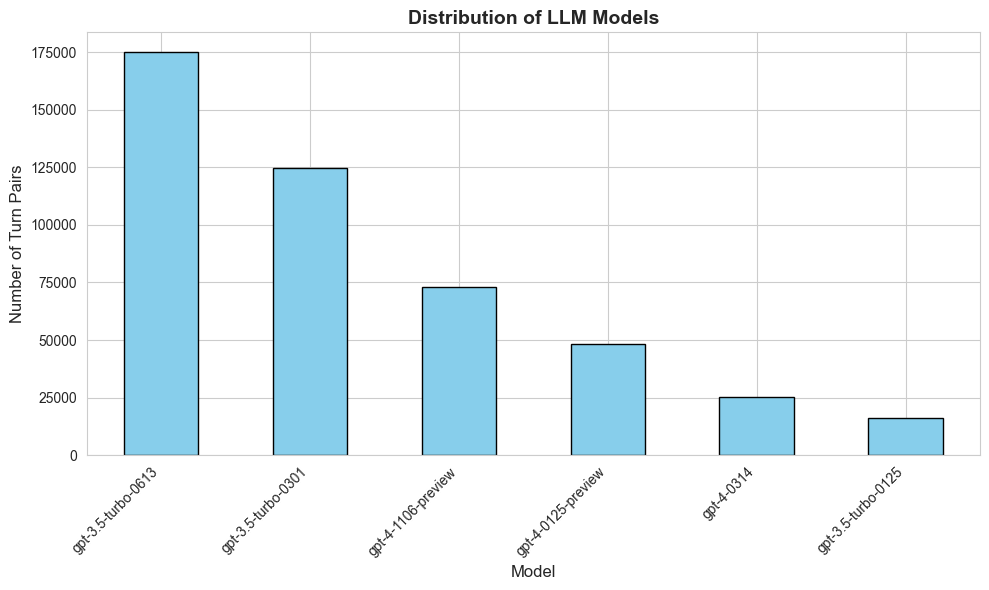

In [ ]:
model_counts = df['model'].value_counts()
model_percentages = (model_counts / len(df) * 100).round(2)

print("Model Distribution:")
print("="*60)
print(f"{'Model':<40} {'Count':>8} {'Percentage':>10}")
print("-"*60)
for model, count in model_counts.items():
    pct = model_percentages[model]
    print(f"{model:<40} {count:>8} {pct:>9.2f}%")
print("-"*60)
print(f"{'Total':<40} {len(df):>8} {'100.00%':>10}")

plt.figure(figsize=(10, 6))
model_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of LLM Models', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Number of Turn Pairs', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5.2 Conversation Length Distribution

Conversation Length Distribution:
 Turns      Count   Percentage   Cumulative %
------------------------------------------------------------
     4      60052       12.99%         12.99%
     6      60886       13.17%         26.16%
     8      52857       11.43%         37.59%
    10      43628        9.43%         47.02%
    12      37955        8.21%         55.23%
    14      31644        6.84%         62.07%
    16      26936        5.82%         67.89%
    18      23064        4.99%         72.88%
    20      19242        4.16%         77.04%
    22      15690        3.39%         80.43%
    24      13321        2.88%         83.31%
    26      10464        2.26%         85.57%
    28       9503        2.05%         87.62%
    30       7406        1.60%         89.22%
    32       6360        1.38%         90.60%
    34       5328        1.15%         91.75%
    36       4658        1.01%         92.76%
    38       3492        0.76%         93.52%
    40       3363        0.73% 

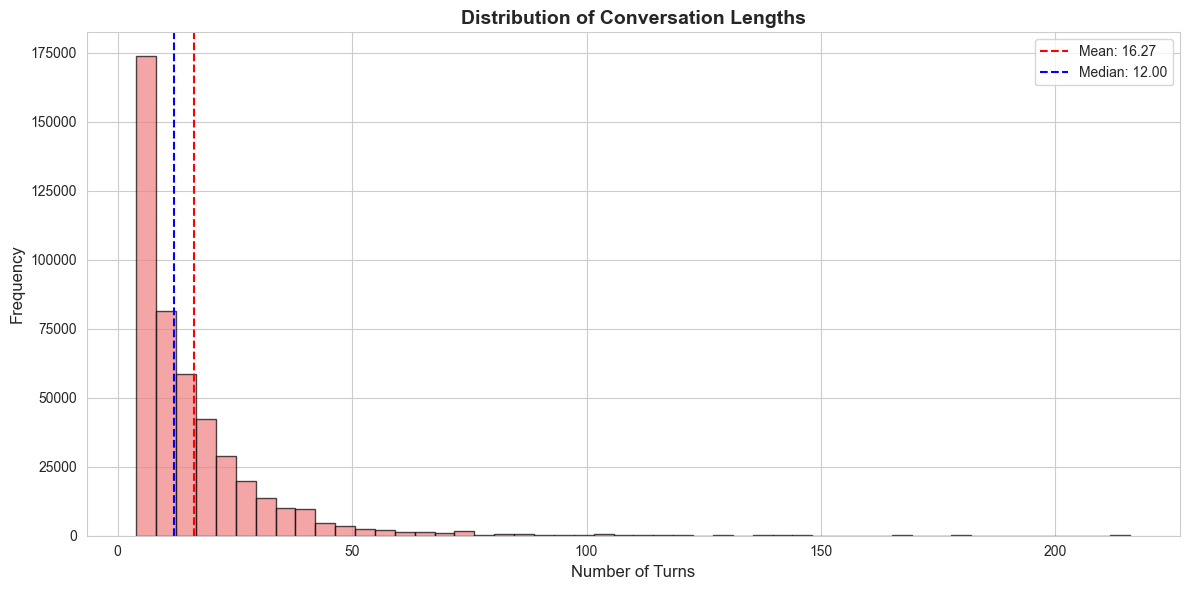

In [ ]:
turn_counts = df['total_turns'].value_counts().sort_index()
turn_percentages = (turn_counts / len(df) * 100).round(2)

print("Conversation Length Distribution:")
print("="*60)
print(f"{'Turns':>6} {'Count':>10} {'Percentage':>12} {'Cumulative %':>14}")
print("-"*60)
cumulative = 0
for turns, count in turn_counts.items():
    pct = turn_percentages[turns]
    cumulative += pct
    print(f"{turns:>6} {count:>10} {pct:>11.2f}% {cumulative:>13.2f}%")
print("-"*60)
print(f"{'Total':>6} {len(df):>10} {'100.00%':>12} {'100.00%':>14}")

print(f"\nSummary statistics:")
print(df['total_turns'].describe())

plt.figure(figsize=(12, 6))
plt.hist(df['total_turns'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
plt.title('Distribution of Conversation Lengths', fontsize=14, fontweight='bold')
plt.xlabel('Number of Turns', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(df['total_turns'].mean(), color='red', linestyle='--', label=f'Mean: {df["total_turns"].mean():.2f}')
plt.axvline(df['total_turns'].median(), color='blue', linestyle='--', label=f'Median: {df["total_turns"].median():.2f}')
plt.legend()
plt.tight_layout()
plt.show()

### 5.4 Time of Day Distribution

Hour of Day Distribution:
 Hour      Count   Percentage            Bar Chart
------------------------------------------------------------
    0      17659        3.82% █
    1      17295        3.74% █
    2      17194        3.72% █
    3      16862        3.65% █
    4      16246        3.51% █
    5      16639        3.60% █
    6      18816        4.07% ██
    7      19205        4.15% ██
    8      19514        4.22% ██
    9      19676        4.25% ██
   10      19090        4.13% ██
   11      18894        4.09% ██
   12      20172        4.36% ██
   13      20849        4.51% ██
   14      21487        4.65% ██
   15      21554        4.66% ██
   16      21595        4.67% ██
   17      21804        4.71% ██
   18      21885        4.73% ██
   19      20742        4.49% ██
   20      20110        4.35% ██
   21      19010        4.11% ██
   22      18027        3.90% █
   23      18147        3.92% █
------------------------------------------------------------
Total     462472 

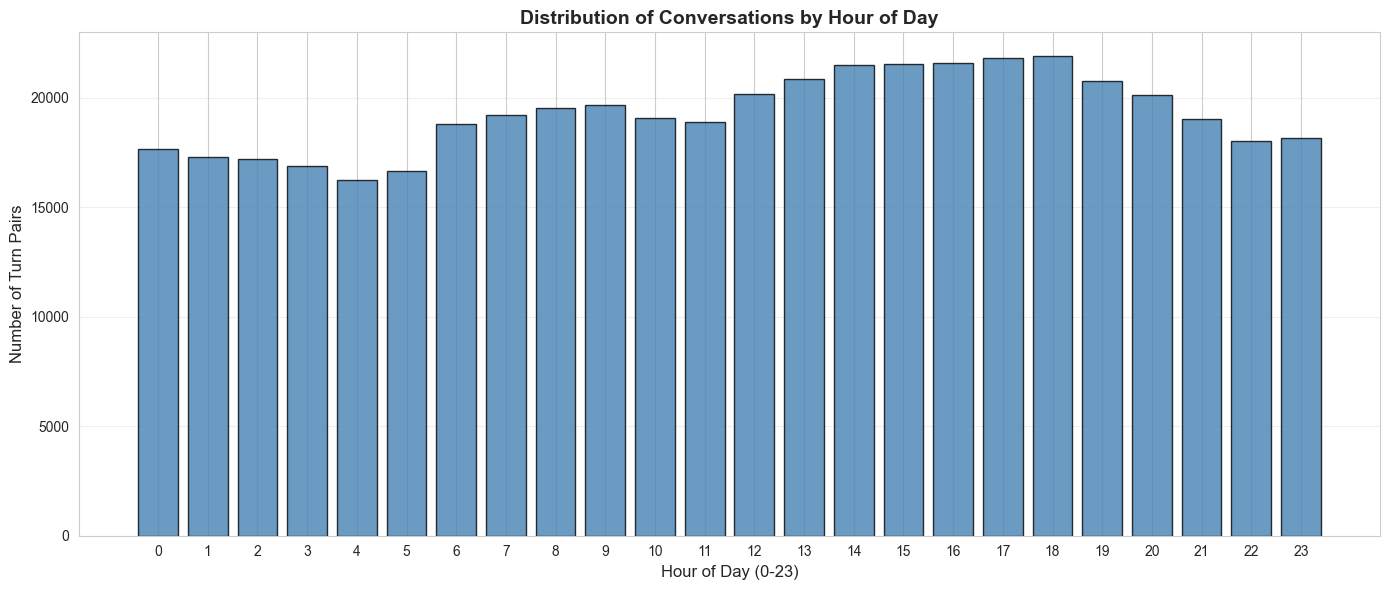

In [ ]:
hour_counts = df['hour_of_day'].value_counts().sort_index()
hour_percentages = (hour_counts / len(df) * 100).round(2)

print("Hour of Day Distribution:")
print("="*60)
print(f"{'Hour':>5} {'Count':>10} {'Percentage':>12} {'Bar Chart':>20}")
print("-"*60)
for hour in range(24):
    count = hour_counts.get(hour, 0)
    pct = hour_percentages.get(hour, 0.0)
    bar = '█' * int(pct / 2)  # Scale bar for display
    print(f"{hour:>5} {count:>10} {pct:>11.2f}% {bar}")
print("-"*60)
print(f"{'Total':>5} {len(df):>10} {'100.00%':>12}")

print(f"\nSummary statistics:")
print(df['hour_of_day'].describe())
print(f"\nPeak hours (top 5):")
for hour, count in hour_counts.nlargest(5).items():
    pct = hour_percentages[hour]
    print(f"  Hour {hour:2d}: {count:>6} turn pairs ({pct:>5.2f}%)")

plt.figure(figsize=(14, 6))
plt.bar(hour_counts.index, hour_counts.values, color='steelblue', edgecolor='black', alpha=0.8)
plt.title('Distribution of Conversations by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Number of Turn Pairs', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Turn Position Distribution:
Position      Count   Percentage
------------------------------------------------------------
       1     148042       32.01%
       3      87990       19.03%
       5      57547       12.44%
       7      39928        8.63%
       9      29021        6.28%
      11      21430        4.63%
      13      16156        3.49%
      15      12308        2.66%
      17       9425        2.04%
      19       7287        1.58%
      21       5718        1.24%
      23       4507        0.97%
      25       3635        0.79%
      27       2904        0.63%
      29       2375        0.51%
      31       1951        0.42%
      33       1618        0.35%
      35       1344        0.29%
      37       1150        0.25%
      39        973        0.21%
     ...        ...          ...
     209          1        0.00%
     211          1        0.00%
     213          1        0.00%
------------------------------------------------------------
   Total     462472      

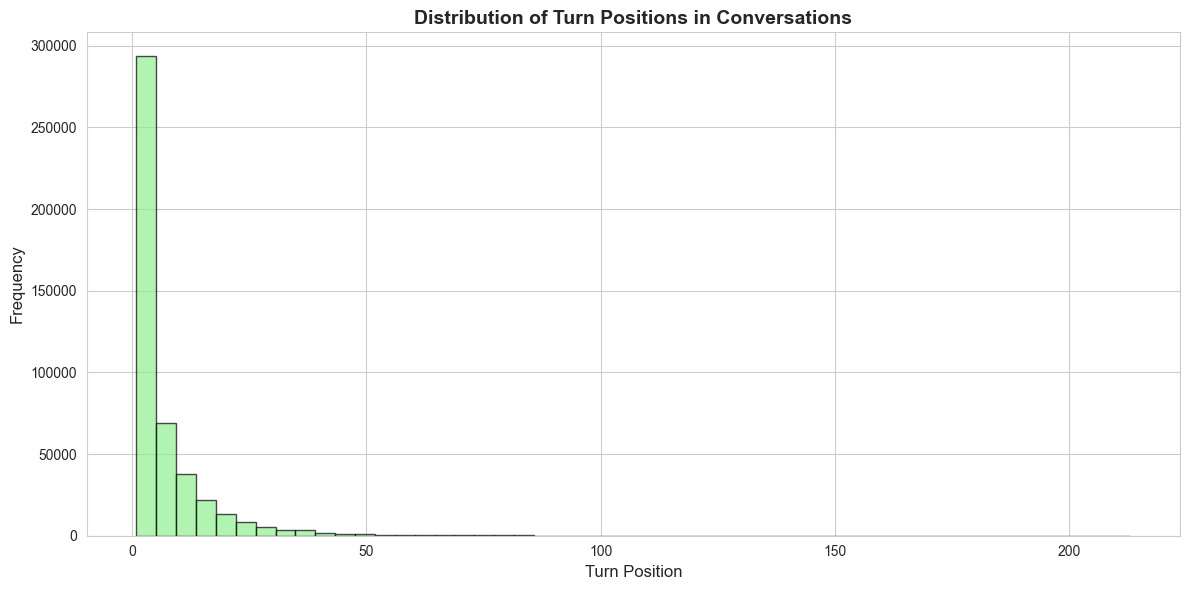

In [ ]:
position_counts = df['turn_number'].value_counts().sort_index()
position_percentages = (position_counts / len(df) * 100).round(2)

print("Turn Position Distribution:")
print("="*60)
print(f"{'Position':>8} {'Count':>10} {'Percentage':>12}")
print("-"*60)
for pos in sorted(position_counts.index)[:20]:
    count = position_counts[pos]
    pct = position_percentages[pos]
    print(f"{pos:>8} {count:>10} {pct:>11.2f}%")
if len(position_counts) > 20:
    print(f"{'...':>8} {'...':>10} {'...':>12}")
    for pos in sorted(position_counts.index)[-3:]:
        count = position_counts[pos]
        pct = position_percentages[pos]
        print(f"{pos:>8} {count:>10} {pct:>11.2f}%")
print("-"*60)
print(f"{'Total':>8} {len(df):>10} {'100.00%':>12}")

print(f"\nSummary statistics:")
print(df['turn_number'].describe())

plt.figure(figsize=(12, 6))
plt.hist(df['turn_number'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
plt.title('Distribution of Turn Positions in Conversations', fontsize=14, fontweight='bold')
plt.xlabel('Turn Position', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

### 5.4 Text Length Analysis


User Prompt Length Distribution (by character range):
          Range      Count   Percentage
------------------------------------------------------------
           0-50     138052       29.85%
         51-100     100181       21.66%
        101-200      74872       16.19%
        201-500      65098       14.08%
       501-1000      30735        6.65%
      1001-2000      20214        4.37%
      2001-5000      19142        4.14%
          5000+      14178        3.07%
------------------------------------------------------------
          Total     462472      100.00%

LLM Response Length Distribution (by character range):
          Range      Count   Percentage
------------------------------------------------------------
           0-50      22012        4.76%
         51-100      17333        3.75%
        101-200      27520        5.95%
        201-500      61457       13.29%
       501-1000      77711       16.80%
      1001-2000     116443       25.18%
      2001-5000     134119

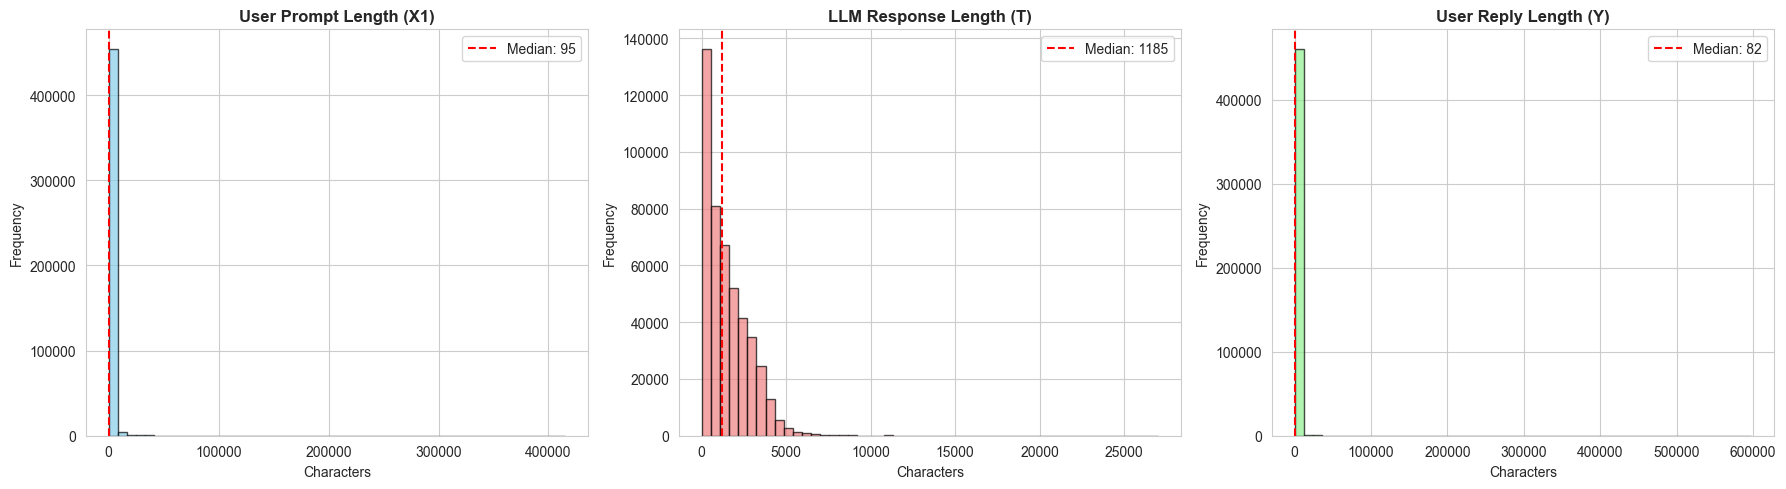

In [ ]:
df['user_prompt_length'] = df['user_prompt'].str.len()
df['llm_response_length'] = df['llm_response'].str.len()
df['user_reply_length'] = df['user_reply'].str.len()

def create_length_bins(series, name):
    bins = [0, 50, 100, 200, 500, 1000, 2000, 5000, float('inf')]
    labels = ['0-50', '51-100', '101-200', '201-500', '501-1000', '1001-2000', '2001-5000', '5000+']
    binned = pd.cut(series, bins=bins, labels=labels, include_lowest=True)
    counts = binned.value_counts().sort_index()
    percentages = (counts / len(series) * 100).round(2)
    
    print(f"\n{name} Length Distribution (by character range):")
    print("="*60)
    print(f"{'Range':>15} {'Count':>10} {'Percentage':>12}")
    print("-"*60)
    for label, count in counts.items():
        pct = percentages[label]
        print(f"{label:>15} {count:>10} {pct:>11.2f}%")
    print("-"*60)
    print(f"{'Total':>15} {len(series):>10} {'100.00%':>12}")

create_length_bins(df['user_prompt_length'], "User Prompt")
create_length_bins(df['llm_response_length'], "LLM Response")
create_length_bins(df['user_reply_length'], "User Reply")

print("\n" + "="*60)
print("Detailed Statistics:")
print("="*60)
print("\nUser Prompt Length:")
print(df['user_prompt_length'].describe())
print("\nLLM Response Length:")
print(df['llm_response_length'].describe())
print("\nUser Reply Length:")
print(df['user_reply_length'].describe())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['user_prompt_length'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('User Prompt Length (X1)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Characters', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].axvline(df['user_prompt_length'].median(), color='red', linestyle='--', label=f'Median: {df["user_prompt_length"].median():.0f}')
axes[0].legend()

axes[1].hist(df['llm_response_length'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].set_title('LLM Response Length (T)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Characters', fontsize=10)
axes[1].set_ylabel('Frequency', fontsize=10)
axes[1].axvline(df['llm_response_length'].median(), color='red', linestyle='--', label=f'Median: {df["llm_response_length"].median():.0f}')
axes[1].legend()

axes[2].hist(df['user_reply_length'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[2].set_title('User Reply Length (Y)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Characters', fontsize=10)
axes[2].set_ylabel('Frequency', fontsize=10)
axes[2].axvline(df['user_reply_length'].median(), color='red', linestyle='--', label=f'Median: {df["user_reply_length"].median():.0f}')
axes[2].legend()

plt.tight_layout()
plt.show()

### 5.5 User Activity Distribution

User Activity Distribution (Turn Pairs per User):
  Turn Pairs      Users   Percentage
------------------------------------------------------------
           1      17682       30.27%
           2      10039       17.19%
         3-4      10576       18.11%
         5-9      10230       17.51%
       10-19       5622        9.62%
       20-49       3054        5.23%
         50+       1210        2.07%
------------------------------------------------------------
       Total      58413      100.00%

Summary statistics:
count    58413.000000
mean         7.917279
std         32.217134
min          1.000000
25%          1.000000
50%          3.000000
75%          6.000000
max       2764.000000
Name: count, dtype: float64

Key insights:
  - Users with only 1 turn pair: 17,682 (30.27%)
  - Users with 2-5 turn pairs: 23,731
  - Users with 6-10 turn pairs: 8,132
  - Users with >10 turn pairs: 8,868 (15.18%)
  - Most active user: 2764 turn pairs


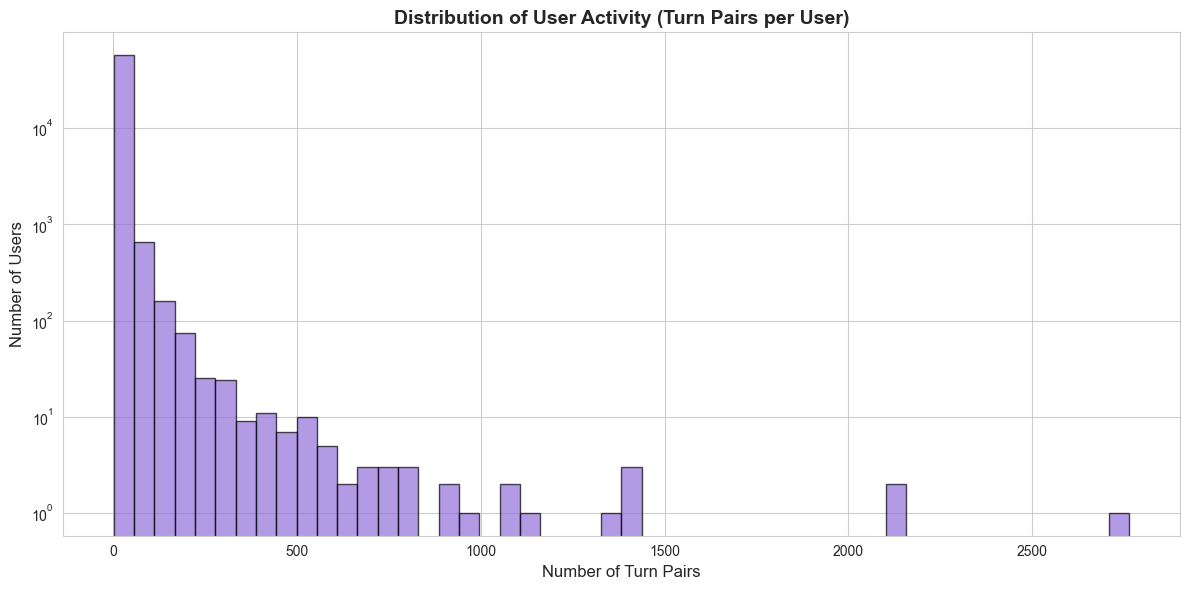

In [ ]:
user_activity = df['user_id'].value_counts()

activity_bins = [1, 2, 3, 5, 10, 20, 50, float('inf')]
activity_labels = ['1', '2', '3-4', '5-9', '10-19', '20-49', '50+']
binned_activity = pd.cut(user_activity, bins=activity_bins, labels=activity_labels, include_lowest=True, right=False)
activity_counts = binned_activity.value_counts().sort_index()
activity_percentages = (activity_counts / len(user_activity) * 100).round(2)

print("User Activity Distribution (Turn Pairs per User):")
print("="*60)
print(f"{'Turn Pairs':>12} {'Users':>10} {'Percentage':>12}")
print("-"*60)
for label, count in activity_counts.items():
    pct = activity_percentages[label]
    print(f"{label:>12} {count:>10} {pct:>11.2f}%")
print("-"*60)
print(f"{'Total':>12} {len(user_activity):>10} {'100.00%':>12}")

print(f"\nSummary statistics:")
print(user_activity.describe())

print(f"\nKey insights:")
print(f"  - Users with only 1 turn pair: {(user_activity == 1).sum():,} ({(user_activity == 1).sum()/len(user_activity)*100:.2f}%)")
print(f"  - Users with 2-5 turn pairs: {((user_activity >= 2) & (user_activity <= 5)).sum():,}")
print(f"  - Users with 6-10 turn pairs: {((user_activity >= 6) & (user_activity <= 10)).sum():,}")
print(f"  - Users with >10 turn pairs: {(user_activity > 10).sum():,} ({(user_activity > 10).sum()/len(user_activity)*100:.2f}%)")
print(f"  - Most active user: {user_activity.max()} turn pairs")

plt.figure(figsize=(12, 6))
plt.hist(user_activity, bins=50, color='mediumpurple', edgecolor='black', alpha=0.7)
plt.title('Distribution of User Activity (Turn Pairs per User)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Turn Pairs', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.yscale('log')
plt.tight_layout()
plt.show()

### 5.6 Geographic Distribution

Geographic Distribution (Top 20 Countries):
Country                               Count   Percentage   Cumulative
----------------------------------------------------------------------
 1. United States                     112433       24.31%       24.31%
 2. Russia                             35986        7.78%       32.09%
 3. United Kingdom                     29922        6.47%       38.56%
 4. India                              25752        5.57%       44.13%
 5. Canada                             18316        3.96%       48.09%
 6. Hong Kong                          15159        3.28%       51.37%
 7. China                              14216        3.07%       54.44%
 8. Philippines                        13303        2.88%       57.32%
 9. Egypt                              12359        2.67%       59.99%
10. Germany                            11675        2.52%       62.51%
11. Australia                          11302        2.44%       64.95%
12. France                        

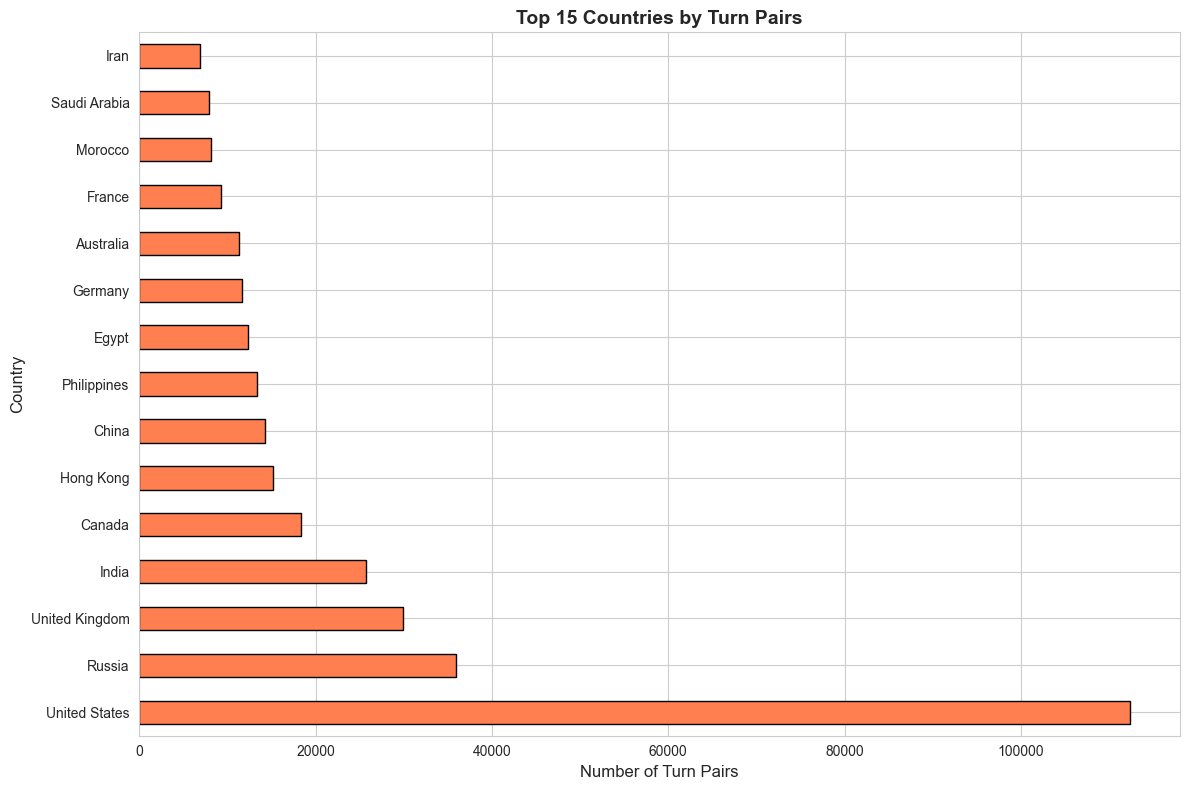

In [ ]:
country_counts = df['country'].value_counts()
country_percentages = (country_counts / len(df) * 100).round(2)

print("Geographic Distribution (Top 20 Countries):")
print("="*70)
print(f"{'Country':<30} {'Count':>12} {'Percentage':>12} {'Cumulative':>12}")
print("-"*70)
cumulative = 0
for i, (country, count) in enumerate(country_counts.head(20).items(), 1):
    pct = country_percentages[country]
    cumulative += pct
    print(f"{i:2d}. {country:<27} {count:>12} {pct:>11.2f}% {cumulative:>11.2f}%")
print("-"*70)
other_countries = len(country_counts) - 20
if other_countries > 0:
    other_count = country_counts.iloc[20:].sum()
    other_pct = (other_count / len(df) * 100)
    print(f"    {'Other (' + str(other_countries) + ' countries)':<27} {other_count:>12} {other_pct:>11.2f}% {'100.00%':>12}")
    print("-"*70)
print(f"{'Total':<30} {len(df):>12} {'100.00%':>12}")

print(f"\nGeographic coverage:")
print(f"  - Total unique countries: {len(country_counts)}")
print(f"  - Top 5 countries account for: {country_percentages.head(5).sum():.2f}%")
print(f"  - Top 10 countries account for: {country_percentages.head(10).sum():.2f}%")

plt.figure(figsize=(12, 8))
top_15 = country_counts.head(15)
top_15.plot(kind='barh', color='coral', edgecolor='black')
plt.title('Top 15 Countries by Turn Pairs', fontsize=14, fontweight='bold')
plt.xlabel('Number of Turn Pairs', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.show()

### 5.7 Data Quality Checks

In [ ]:
print("\n" + "="*50)
print("Empty content check:")
print(f"Empty user prompts: {(df['user_prompt'].str.len() == 0).sum()}")
print(f"Empty LLM responses: {(df['llm_response'].str.len() == 0).sum()}")
print(f"Empty user replies: {(df['user_reply'].str.len() == 0).sum()}")

print("\n" + "="*50)
print("Missing values:")
print(df.isnull().sum())


Empty content check:
Empty user prompts: 3974
Empty LLM responses: 0
Empty user replies: 4596

Missing values:
conversation_hash        0
turn_pair_id             0
model                    0
user_id                  0
turn_number              0
total_turns              0
timestamp                0
hour_of_day              0
user_prompt              0
llm_response             0
user_reply               0
turn_identifier          0
hashed_ip                0
country                439
user_prompt_length       0
llm_response_length      0
user_reply_length        0
dtype: int64
Empty LLM responses: 0
Empty user replies: 4596

Missing values:
conversation_hash        0
turn_pair_id             0
model                    0
user_id                  0
turn_number              0
total_turns              0
timestamp                0
hour_of_day              0
user_prompt              0
llm_response             0
user_reply               0
turn_identifier          0
hashed_ip                0


## 6. Summary

### Key Takeaways:

1. **Preprocessing Complete**: Successfully filtered and flattened the WildChat-1M dataset
2. **Data Structure**: Each row now represents a turn-pair with:
   - **T (Treatment)**: LLM's response (to be scored for empathy)
   - **Y (Outcome)**: User's subsequent reply (to be scored for attachment)
   - **X1 (Confounder)**: User's initial prompt
   - **X2 (Confounder)**: User ID (latent traits)
   - **X3 (Confounder)**: Conversation context (turn position, length, timestamp)
   - **X4 (Confounder)**: Model ID

### Next Steps:

1. **LLM-as-a-Judge Scoring**: Apply empathy scoring to `llm_response` and attachment scoring to `user_reply`
2. **Embedding Generation**: Create embeddings for `user_prompt` (X1) for matching
3. **Propensity Score Matching**: Use the confounders to create matched pairs
4. **Causal Analysis**: Estimate the effect of LLM empathy on user attachment

In [33]:
print("\n" + "="*70)
print("PREPROCESSING COMPLETE!")
print("="*70)
print(f"\n✓ Sample dataset saved to: {sample_output_path}")
print(f"  - Rows: {len(df_sample_processed):,}")
print(f"  - Size: {os.path.getsize(sample_output_path) / (1024*1024):.2f} MB")
print(f"\n✓ Full dataset saved to: {full_output_path}")
print(f"  - Rows: {len(df_full_processed):,}")
print(f"  - Size: {os.path.getsize(full_output_path) / (1024*1024):.2f} MB")
print("\n" + "="*70)


PREPROCESSING COMPLETE!

✓ Sample dataset saved to: ../data/filtered/wildchat_sample_preprocessed_v2.csv
  - Rows: 595
  - Size: 1.61 MB

✓ Full dataset saved to: ../data/filtered/wildchat_full_preprocessed_v2.csv
  - Rows: 462,472
  - Size: 1398.94 MB

